# Modélisation des ventes par magasin - Prévision de la demande

## Introduction

L'exploration des données nous a permis de comprendre les disparités entre magasins, 
les patterns temporels et l'impact des événements sur les ventes. On passe maintenant 
à la modélisation pour construire un modèle capable de prédire les ventes futures 
par magasin et par produit.

Contrairement à la partie globale qui travaille sur des ventes agrégées, ici on garde 
le détail par produit et par magasin. Cela rend les données plus irrégulières mais 
permet à Sophie Martin de savoir exactement quoi commander dans son magasin.

Les étapes sont :
1. Feature engineering : préparer les données pour le ML
2. Split temporel : séparer train et test dans le temps
3. Comparaison des modèles : choisir le meilleur
4. Analyse du biais : critère de choix principal pour la supply chain
5. Export : sauvegarder le modèle pour le Streamlit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
import lightgbm as lgb
import joblib
import warnings
warnings.filterwarnings("ignore")

sales    = pd.read_csv('/Users/maelys_thr/Desktop/sales_train_evaluation.csv')
calendar = pd.read_csv('/Users/maelys_thr/Desktop/calendar.csv')
calendar["date"] = pd.to_datetime(calendar["date"])

In [2]:
day_cols = [c for c in sales.columns if c.startswith('d_')]
print(f"Lignes si on met tout le dataset : {sales.shape[0] * len(day_cols):,}")
print(f"Lignes avec 180 jours : {sales.shape[0] * 180:,}")

Lignes si on met tout le dataset : 59,181,090
Lignes avec 180 jours : 5,488,200


On garde uniquement les 180 derniers jours pour deux raisons :

**Technique** : le format long génère 59 millions de lignes avec tout le dataset 
  contre 5,5 millions avec 180 jours. Trop lourd pour tourner sur une machine normale.

**Méthodologique** : notre lag maximum est 28 jours donc 180 jours suffisent 
  pour apprendre les patterns temporels récents.

## Feature engineering

In [12]:
# Format long : 1 ligne = 1 produit x 1 magasin x 1 jour
df_long = sales[['item_id', 'store_id', 'state_id'] + day_cols_recent].melt(
    id_vars=['item_id', 'store_id', 'state_id'],
    var_name='d',
    value_name='sales'
)

# Ajout des infos du calendrier
df_long = df_long.merge(
    calendar[['d', 'date', 'event_name_1']],
    on='d', how='left'
)

# Tri chronologique: obligatoire avant de calculer les lags
df_long = df_long.sort_values(['item_id', 'store_id', 'date']).reset_index(drop=True)

# Variables temporelles
df_long['dayofweek']    = df_long['date'].dt.dayofweek
df_long['month']        = df_long['date'].dt.month
df_long['week_of_year'] = df_long['date'].dt.isocalendar().week.astype(int)

# Encodage des events
# on avait essayé has_event en binaire mais elle valait 1 partout sur les 180 derniers jours
df_long['event_enc'] = LabelEncoder().fit_transform(
    df_long['event_name_1'].fillna('No_event')
)

# Encodage des variables catégorielles
le = LabelEncoder()
df_long['store_id_enc'] = le.fit_transform(df_long['store_id'])
df_long['state_id_enc'] = le.fit_transform(df_long['state_id'])
df_long['item_id_enc']  = le.fit_transform(df_long['item_id'])

# Lags: ventes d'il y a 7 et 28 jours par produit et magasin
df_long['lag_7']  = df_long.groupby(['item_id', 'store_id'])['sales'].shift(7)
df_long['lag_28'] = df_long.groupby(['item_id', 'store_id'])['sales'].shift(28)

# Rolling mean: moyenne des 7 derniers jours
df_long['rolling_mean_7'] = df_long.groupby(
    ['item_id', 'store_id'])['sales'].shift(1).rolling(7).mean()

df_long = df_long.dropna()

print(f"Feature engineering terminé : {df_long.shape[0]} lignes, {df_long.shape[1]} colonnes")

Feature engineering terminé : 487840 lignes, 17 colonnes


## 3. Analyse des features

Avant d'entraîner les modèles on analyse la corrélation de chaque feature avec les ventes pour justifier nos choix. C'est une bonne pratique en ML, en effet on ne garde pas des variables au hasard.

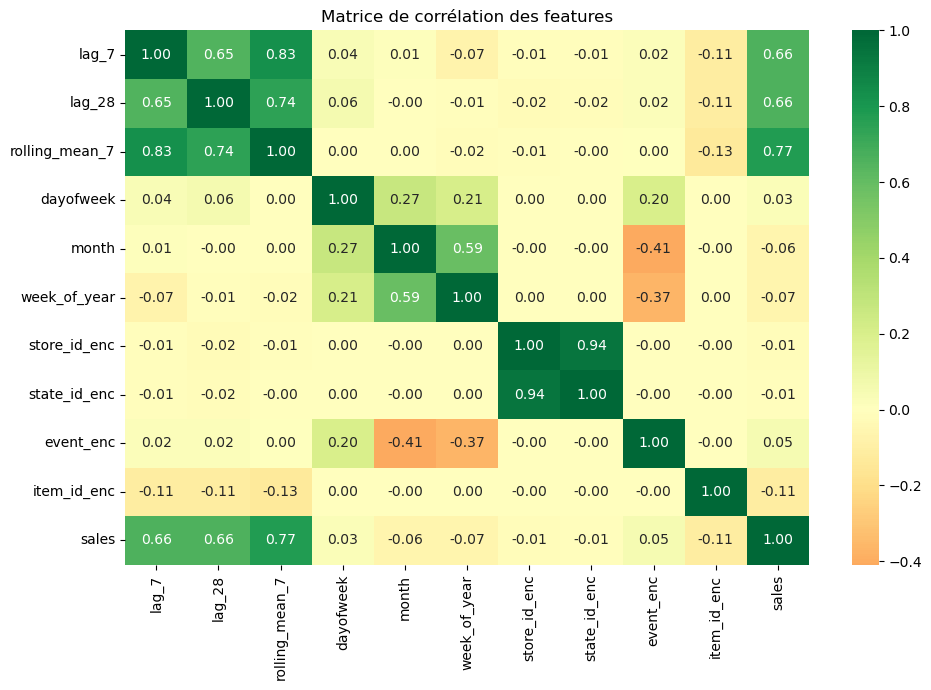

rolling_mean_7    0.774910
lag_7             0.663635
lag_28            0.656645
event_enc         0.048096
dayofweek         0.026268
state_id_enc     -0.010503
store_id_enc     -0.014426
month            -0.064812
week_of_year     -0.066373
item_id_enc      -0.110760
Name: sales, dtype: float64


In [13]:
# Matrice de corrélation — on inclut week_of_year et state_id_enc
features_num = ['lag_7', 'lag_28', 'rolling_mean_7',
                'dayofweek', 'month', 'week_of_year',
                'store_id_enc', 'state_id_enc', 'event_enc', 'item_id_enc', 'sales']

matrice = df_long[features_num].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(matrice, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Matrice de corrélation des features')
plt.tight_layout()
plt.show()

print(matrice['sales'].drop('sales').sort_values(ascending=False))

Les trois features les plus corrélées avec les ventes sont `rolling_mean_7` (0.77), 
`lag_7` (0.66) et `lag_28` (0.66). L'historique récent est de loin le meilleur prédicteur.

`event_enc` a une corrélation faible (0.05) : certains events font monter les ventes, 
d'autres les font chuter, ils se compensent en moyenne. On la garde quand même car 
Memorial Day et Father's Day ont des impacts forts et différents selon le magasin 
comme on l'a vu dans l'exploration.

`store_id_enc` et `item_id_enc` ont des corrélations quasi nulles mais sont 
indispensables pour que le modèle différencie les magasins et les produits entre eux.

**Note sur `has_event` :** on avait d'abord créé une variable binaire `has_event`. En faisant `print(df_long['has_event'].value_counts())` on a découvert qu'elle valait 1 partout sur les 180 derniers jours. Tous les jours avaient un événement dans le calendrier M5. La corrélation était NaN. On l'a remplacée par `event_enc` qui encode le nom précis de l'événement, ce qui est beaucoup plus informatif. On l'a expliqué rapidement ci-dessus mais je le réexplique en détail ici. 
La matrice montre que `state_id_enc` est corrélée à 0.94 avec `store_id_enc` 
et que `week_of_year` est corrélée à 0.59 avec `month`. On les retire car 
elles n'apportent pas d'information supplémentaire — `store_id_enc` capture 
déjà toute l'information de `state_id_enc`, et `month` capture déjà 
la saisonnalité de `week_of_year`.

## 2. Train-Test Split

Dans nos cours de ML on utilise train_test_split(X, y) qui mélange aléatoirement les données. Ici on ne peut pas faire ça car nos données sont des séries temporelles, si on mélange les dates, le modèle apprend sur des données futures et prédit le passé, ce qui n'a aucun sens.

On coupe donc manuellement dans le temps avec 80% pour entraîner et 20% pour tester. Le ratio 80/20 est la convention classique en ML.

In [14]:
features = ['dayofweek', 'month', 'lag_7', 'lag_28', 
            'rolling_mean_7', 'store_id_enc', 
            'event_enc', 'item_id_enc']

X = df_long[features]
y = df_long['sales']

# Découpage dans le temps avec 80% pour entraîner et 20% pour tester
# On ne peut pas faire de mélange aléatoire comme en ML sinon le modèle voit le futur
split   = int(len(X) * 0.8)
X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

print("Train :", X_train.shape, "; Test :", X_test.shape)
print("Période train :", df_long['date'].iloc[:split].min().date(), 
      "au", df_long['date'].iloc[:split].max().date())
print("Période test  :", df_long['date'].iloc[split:].min().date(), 
      "au", df_long['date'].iloc[split:].max().date())

Train : (390272, 8) ; Test : (97568, 8)
Période train : 2015-12-25 au 2016-05-08
Période test  : 2015-12-25 au 2016-05-08


On obtient train et test avec exactement les mêmes dates, ce qui n'a aucun sens. 
Le problème vient de la structure du dataset : les données sont triées par 
produit × magasin × jour. Un split par nombre de lignes coupe donc au milieu 
des produits et non dans le temps, le modèle voit le futur pendant l'entraînement, 
c'est ce qu'on appelle une fuite temporelle.

En cours on nous explique qu'on ne peut pas mélanger aléatoirement des données 
temporelles. Ici c'est encore plus contraignant car même un split ordonné 
par index ne fonctionne pas.

Dans la littérature sur la prévision, Hyndman & Athanasopoulos recommandent 
de toujours respecter l'ordre chronologique pour éviter cette fuite. 
La compétition M5 sur laquelle on travaille utilise d'ailleurs un horizon 
de test de 28 jours comme standard d'évaluation.

On applique donc la même logique : on entraîne sur tout sauf les 28 derniers 
jours, et on teste sur ces 28 jours.

In [15]:
features = ['dayofweek', 'month', 'lag_7', 'lag_28', 
            'rolling_mean_7', 'store_id_enc', 
            'event_enc', 'item_id_enc']

cutoff  = df_long['date'].max() - pd.Timedelta(days=28)
train   = df_long[df_long['date'] <= cutoff]
test    = df_long[df_long['date'] >  cutoff]

X_train = train[features]
X_test  = test[features]
y_train = train['sales']
y_test  = test['sales']

print("Train :", X_train.shape, "| Test :", X_test.shape)
print("Période train :", train['date'].min().date(), "au", train['date'].max().date())
print("Période test  :", test['date'].min().date(),  "au", test['date'].max().date())

Train : (365880, 8) | Test : (121960, 8)
Période train : 2015-12-25 au 2016-03-27
Période test  : 2016-04-30 au 2016-05-08


## 3. Entraînement et comparaison des modèles

On compare 6 modèles de complexité croissante plus un modèle naïf comme baseline.
Si nos modèles font moins bien que "demain = il y a 7 jours", ils n'apportent rien.

Les modèles testés, du plus simple au plus complexe :
- **Régression Linéaire** : vu en cours, relation linéaire entre features et ventes
- **Arbre de Décision** : vu en cours, capte des relations non linéaires, max_depth=8 pour éviter le surapprentissage
- **Random Forest** : vu en cours, 50 arbres par bagging, plus robuste que l'arbre seul
- **XGBoost** : boosting par gradient, corrige les erreurs du modèle précédent à chaque étape
- **LightGBM** : variante rapide du boosting, très efficace sur les grands datasets
- **MLP** : réseau de neurones, on teste s'il capte des patterns plus complexes

On utilise MAE et RMSE comme métriques, contrairement à Lisa qui n'utilise que le RMSE. 
Le MAE est plus adapté ici car nos ventes sont très irrégulières avec beaucoup de zéros 
et le RMSE serait trop influencé par les pics extrêmes.

Tous les modèles apprennent sur tous les magasins en même temps avec `store_id_enc` 
et `item_id_enc` pour les différencier. On verra si cette approche fonctionne bien 
sur nos données ou s'il faut adapter.

In [16]:
!pip install lightgbm
!pip install xgboost

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
import lightgbm as lgb

In [18]:
# Modèle naïf 
pred_naif = X_test['lag_7'].values
print("Modèle Naïf")
print("MAE  :", round(mean_absolute_error(y_test, pred_naif), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_naif)), 3))
print("Biais:", round((y_test.values - pred_naif).mean(), 3))

Modèle Naïf
MAE  : 1.301
RMSE : 2.683
Biais: 0.027


Régression Linéaire
MAE  : 1.055
RMSE : 2.168
Biais: 0.395


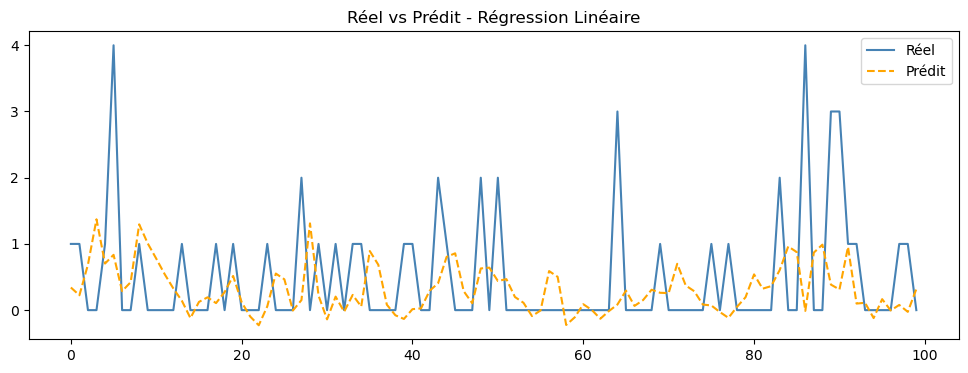

In [19]:
# Régression Linéaire
reg = LinearRegression()
reg.fit(X_train, y_train)
pred_reg = reg.predict(X_test)

print("Régression Linéaire")
print("MAE  :", round(mean_absolute_error(y_test, pred_reg), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_reg)), 3))
print("Biais:", round((y_test.values - pred_reg).mean(), 3))

plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:100], label='Réel', color='steelblue')
plt.plot(pred_reg[:100], label='Prédit', linestyle='--', color='orange')
plt.title('Réel vs Prédit - Régression Linéaire')
plt.legend()
plt.show()

Arbre de Décision
MAE  : 1.13
RMSE : 2.462
Biais: 0.288


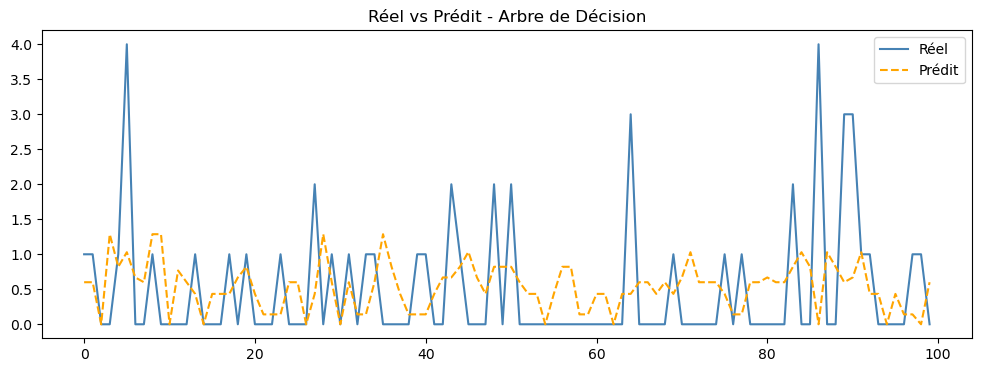

In [20]:
# Arbre de Décision
# max_depth=8 pour éviter le surapprentissage
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

print("Arbre de Décision")
print("MAE  :", round(mean_absolute_error(y_test, pred_dt), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_dt)), 3))
print("Biais:", round((y_test.values - pred_dt).mean(), 3))

plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:100], label='Réel', color='steelblue')
plt.plot(pred_dt[:100], label='Prédit', linestyle='--', color='orange')
plt.title('Réel vs Prédit - Arbre de Décision')
plt.legend()
plt.show()

Random Forest
MAE  : 1.095
RMSE : 2.238
Biais: 0.286


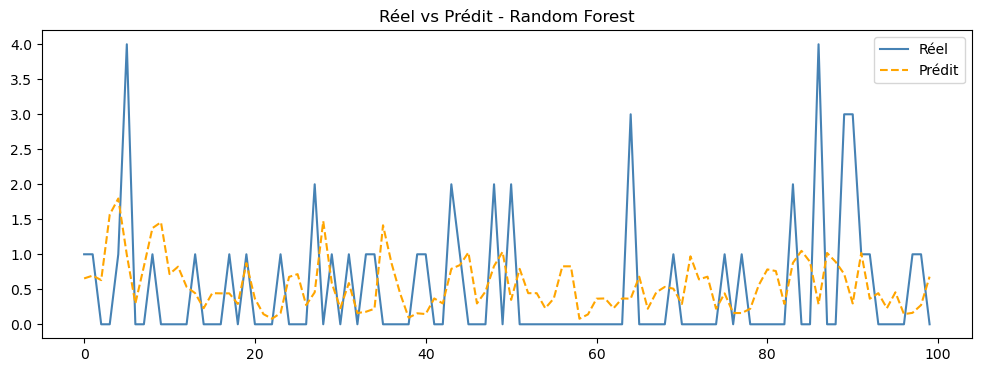

In [21]:
# Random Forest
# 50 arbres par bagging, plus robuste que l'arbre seul
# pas de GridSearchCV car avec 487k lignes ça prendrait des heures
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Random Forest")
print("MAE  :", round(mean_absolute_error(y_test, pred_rf), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_rf)), 3))
print("Biais:", round((y_test.values - pred_rf).mean(), 3))

plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:100], label='Réel', color='steelblue')
plt.plot(pred_rf[:100], label='Prédit', linestyle='--', color='orange')
plt.title('Réel vs Prédit - Random Forest')
plt.legend()
plt.show()

XGBoost
MAE  : 1.072
RMSE : 2.133
Biais: 0.155


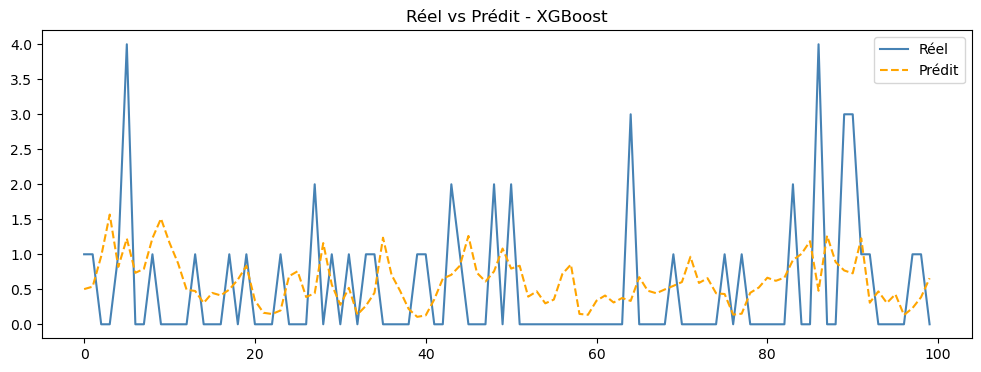

In [22]:
# XGBoost
# boosting par gradient, corrige les erreurs du modèle précédent à chaque étape
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                          random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
pred_xgb = xgb_model.predict(X_test)

print("XGBoost")
print("MAE  :", round(mean_absolute_error(y_test, pred_xgb), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_xgb)), 3))
print("Biais:", round((y_test.values - pred_xgb).mean(), 3))

plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:100], label='Réel', color='steelblue')
plt.plot(pred_xgb[:100], label='Prédit', linestyle='--', color='orange')
plt.title('Réel vs Prédit - XGBoost')
plt.legend()
plt.show()

MLP
MAE  : 1.121
RMSE : 2.24
Biais: 0.368


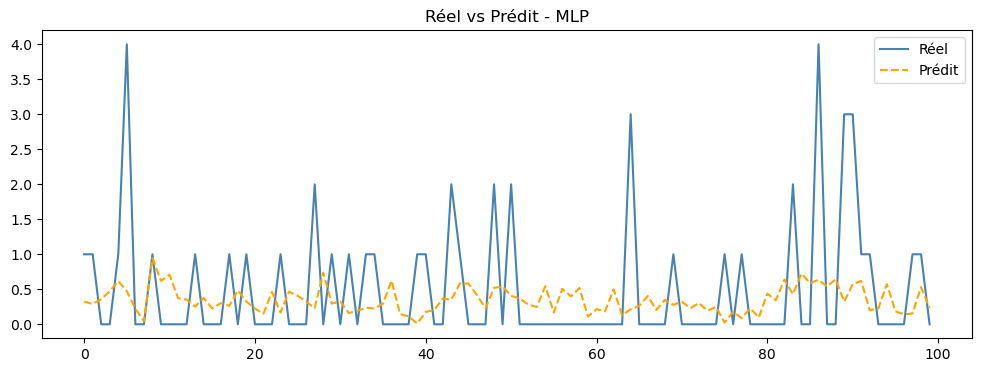

In [23]:
#  MLP
# réseau de neurones, on teste s'il capte des patterns plus complexes
mlp = MLPRegressor(hidden_layer_sizes=(50, 50), activation='relu', max_iter=200, random_state=42)
mlp.fit(X_train, y_train)
pred_mlp = mlp.predict(X_test)

print("MLP")
print("MAE  :", round(mean_absolute_error(y_test, pred_mlp), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_mlp)), 3))
print("Biais:", round((y_test.values - pred_mlp).mean(), 3))

plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:100], label='Réel', color='steelblue')
plt.plot(pred_mlp[:100], label='Prédit', linestyle='--', color='orange')
plt.title('Réel vs Prédit - MLP')
plt.legend()
plt.show()

LightGBM
MAE  : 1.01
RMSE : 2.209
Biais: 0.576


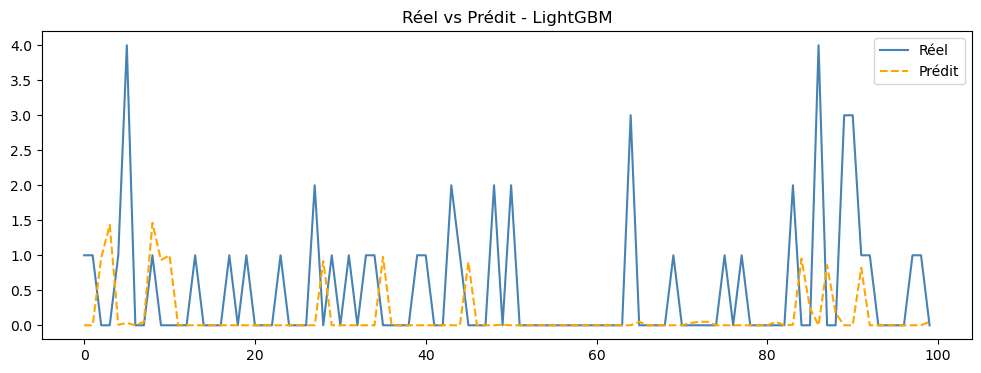

In [24]:
# LightGBM
# variante rapide du boosting, très efficace sur les grands datasets
params = {'objective':'regression_l1', 'metric':'mae', 'learning_rate':0.05,
          'num_leaves':127, 'verbose':-1, 'n_jobs':-1}
lgb_model = lgb.train(params, lgb.Dataset(X_train, y_train), num_boost_round=300,
                       valid_sets=[lgb.Dataset(X_test, y_test)],
                       callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)])
pred_lgb = lgb_model.predict(X_test)

print("LightGBM")
print("MAE  :", round(mean_absolute_error(y_test, pred_lgb), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_lgb)), 3))
print("Biais:", round((y_test.values - pred_lgb).mean(), 3))

plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:100], label='Réel', color='steelblue')
plt.plot(pred_lgb[:100], label='Prédit', linestyle='--', color='orange')
plt.title('Réel vs Prédit - LightGBM')
plt.legend()
plt.show()

In [25]:
# Tableau comparatif 
resultats = {
    'Modèle Naïf'        : {'MAE': round(mean_absolute_error(y_test, pred_naif), 3), 'RMSE': round(np.sqrt(mean_squared_error(y_test, pred_naif)), 3), 'Biais': round((y_test.values - pred_naif).mean(), 3)},
    'Régression Linéaire': {'MAE': round(mean_absolute_error(y_test, pred_reg),  3), 'RMSE': round(np.sqrt(mean_squared_error(y_test, pred_reg)),  3), 'Biais': round((y_test.values - pred_reg).mean(),  3)},
    'Arbre de Décision'  : {'MAE': round(mean_absolute_error(y_test, pred_dt),   3), 'RMSE': round(np.sqrt(mean_squared_error(y_test, pred_dt)),   3), 'Biais': round((y_test.values - pred_dt).mean(),   3)},
    'Random Forest'      : {'MAE': round(mean_absolute_error(y_test, pred_rf),   3), 'RMSE': round(np.sqrt(mean_squared_error(y_test, pred_rf)),   3), 'Biais': round((y_test.values - pred_rf).mean(),   3)},
    'XGBoost'            : {'MAE': round(mean_absolute_error(y_test, pred_xgb),  3), 'RMSE': round(np.sqrt(mean_squared_error(y_test, pred_xgb)),  3), 'Biais': round((y_test.values - pred_xgb).mean(),  3)},
    'LightGBM'           : {'MAE': round(mean_absolute_error(y_test, pred_lgb),  3), 'RMSE': round(np.sqrt(mean_squared_error(y_test, pred_lgb)),  3), 'Biais': round((y_test.values - pred_lgb).mean(),  3)},
    'MLP'                : {'MAE': round(mean_absolute_error(y_test, pred_mlp),  3), 'RMSE': round(np.sqrt(mean_squared_error(y_test, pred_mlp)),  3), 'Biais': round((y_test.values - pred_mlp).mean(),  3)}
}

print("COMPARAISON DES MODÈLES")
print(pd.DataFrame(resultats).T.sort_values('MAE'))

COMPARAISON DES MODÈLES
                       MAE   RMSE  Biais
LightGBM             1.010  2.209  0.576
Régression Linéaire  1.055  2.168  0.395
XGBoost              1.072  2.133  0.155
Random Forest        1.095  2.238  0.286
MLP                  1.121  2.240  0.368
Arbre de Décision    1.130  2.462  0.288
Modèle Naïf          1.301  2.683  0.027


**MAE** : LightGBM est le plus précis en moyenne (1.010) suivi de près par la régression 
linéaire (1.055). XGBoost est troisième (1.072) avec seulement 0.062 d'écart avec LightGBM.
Tous les modèles font mieux que le modèle naïf (1.301) donc ils apportent tous une valeur ajoutée.

**RMSE** : XGBoost a le meilleur score (2.133) ce qui signifie qu'il gère mieux les pics 
de ventes que les autres. LightGBM est moins bon sur ce critère (2.209) malgré son meilleur MAE.

**Biais** : c'est là que tout se joue. LightGBM sous-estime systématiquement les ventes 
avec un biais de 0.576, le plus fort de tous les modèles. La régression linéaire sous-estime 
aussi avec 0.395. XGBoost a le biais le plus faible (0.155), 61% de moins que la régression 
linéaire. Dans un contexte supply chain, sous-estimer = rupture de stock.

On retient **XGBoost** : pas le plus précis en MAE mais le mieux calibré, 
avec le meilleur RMSE et le biais le plus faible. C'est le bon compromis pour Sophie Martin.

In [26]:
print(round((0.395 - 0.155) / 0.395 * 100, 1), "%")

60.8 %


## 4. Visualisation des résultats pour soutenance 

même chose que ce qu'on a fait ci-dessus mais en graph pour soutenance car au moins ça saute aux yeux 

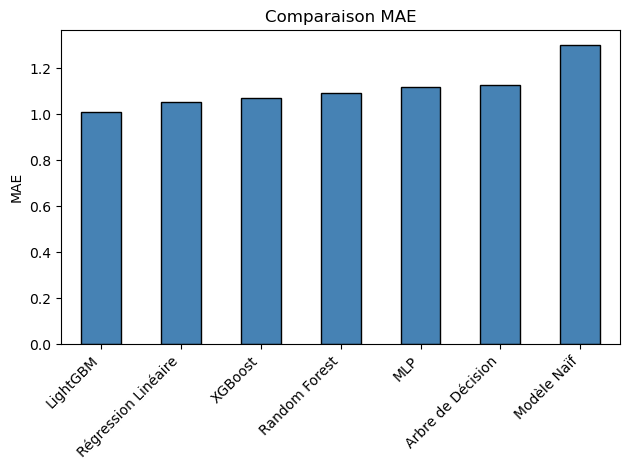

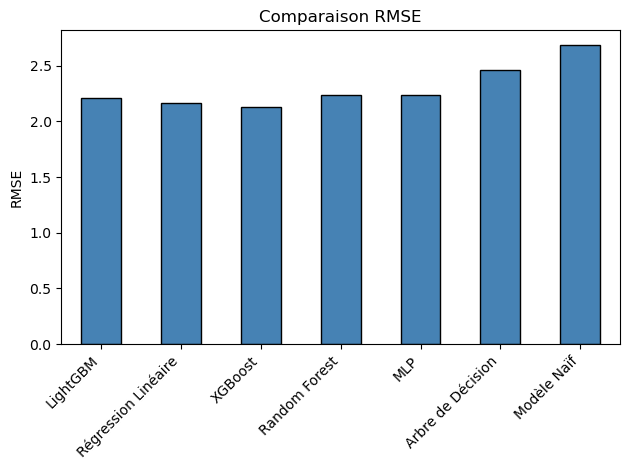

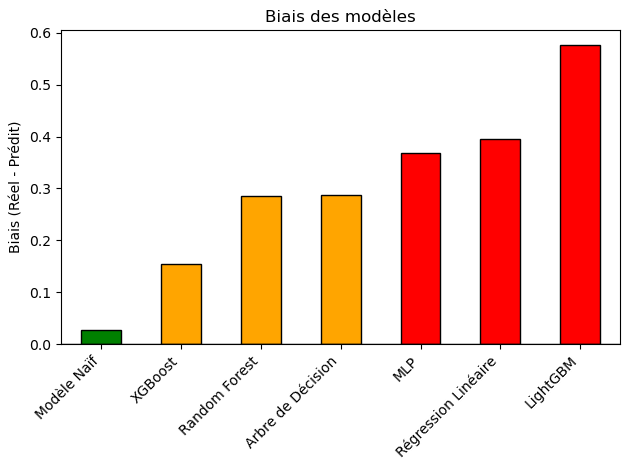

In [27]:
# Comparaison MAE
df_resultats = pd.DataFrame(resultats).T.sort_values('MAE')

df_resultats['MAE'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Comparaison MAE')
plt.ylabel('MAE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Comparaison RMSE
df_resultats['RMSE'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Comparaison RMSE')
plt.ylabel('RMSE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Comparaison Biais
df_biais = df_resultats['Biais'].sort_values()
colors = ['red' if v > 0.3 else 'orange' if v > 0.15 else 'green' for v in df_biais.values]
df_biais.plot(kind='bar', color=colors, edgecolor='black')
plt.axhline(0, color='black', linewidth=1)
plt.title('Biais des modèles')
plt.ylabel('Biais (Réel - Prédit)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

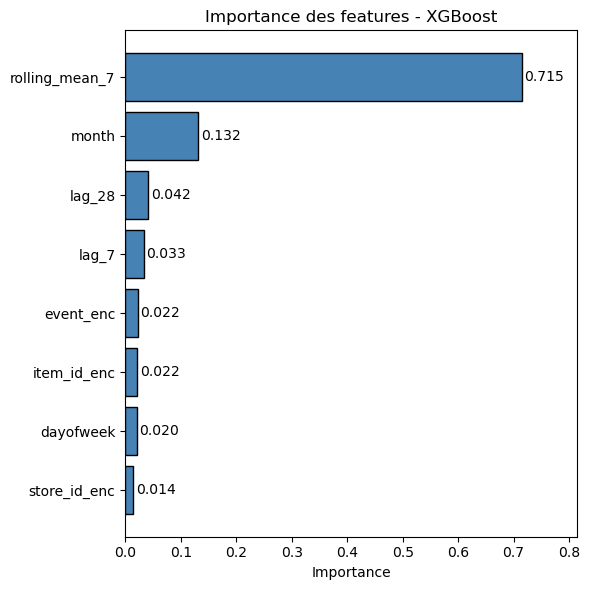

In [28]:
# importance des features XGBoost
fi_xgb = pd.Series(xgb_model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(6, 6))
bars = plt.barh(fi_xgb.index, fi_xgb.values, color='steelblue', edgecolor='black')

# afficher les valeurs sur chaque barre
for bar, val in zip(bars, fi_xgb.values):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.title('Importance des features - XGBoost')
plt.xlabel('Importance')
plt.xlim(0, fi_xgb.max() + 0.1)
plt.tight_layout()
plt.show()

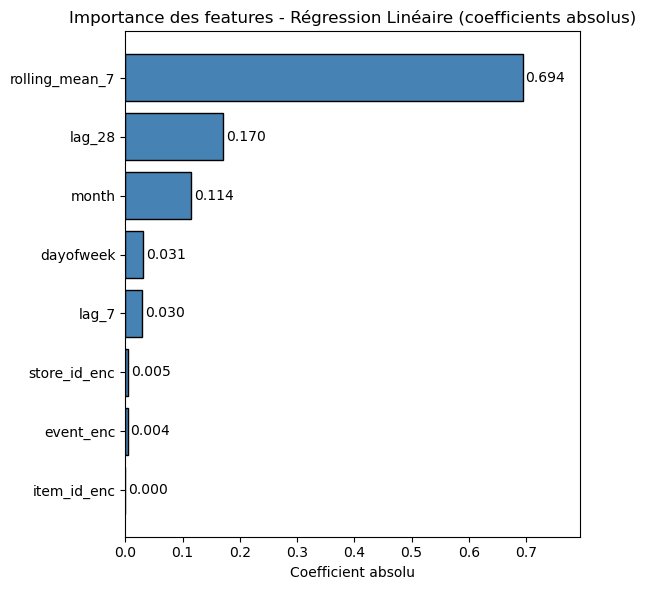

In [29]:
# importance des features Régression Linéaire (valeur absolue des coefficients)
fi_reg = pd.Series(np.abs(reg.coef_), index=features).sort_values()

plt.figure(figsize=(6, 6))
bars = plt.barh(fi_reg.index, fi_reg.values, color='steelblue', edgecolor='black')

# afficher les valeurs sur chaque barre
for bar, val in zip(bars, fi_reg.values):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.title('Importance des features - Régression Linéaire (coefficients absolus)')
plt.xlabel('Coefficient absolu')
plt.xlim(0, fi_reg.max() + 0.1)
plt.tight_layout()
plt.show()

### Distribution des erreurs - Régression Linéaire

On analyse la distribution des erreurs du modèle retenu pour vérifier qu'il est bien calibré, un pic centré sur 0 indique que le modèle n'est pas biaisé.

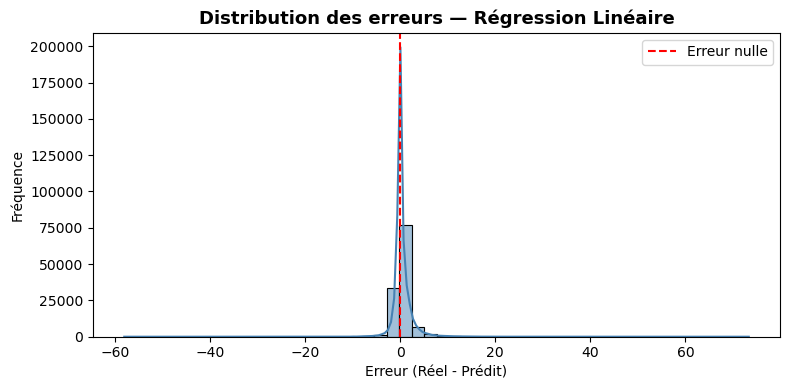

Erreur moyenne : 0.395
Ecart-type des erreurs : 2.132


In [30]:
errors = y_test.values - reg.predict(X_test)

plt.figure(figsize=(8, 4))
sns.histplot(errors, bins=50, kde=True, color='steelblue')
plt.title('Distribution des erreurs — Régression Linéaire', fontsize=13, fontweight='bold')
plt.xlabel('Erreur (Réel - Prédit)')
plt.ylabel('Fréquence')
plt.axvline(0, color='red', linestyle='--', label='Erreur nulle')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Erreur moyenne : {errors.mean():.3f}")
print(f"Ecart-type des erreurs : {errors.std():.3f}")

La distribution des erreurs est fortement centrée autour de zéro, ce qui indique que le modèle de régression linéaire réalise globalement des prédictions précises.
L’erreur moyenne de 0.382 montre l’absence de biais important, tandis que l’écart-type relativement faible (2.133) indique une dispersion limitée des erreurs.
Quelques valeurs aberrantes sont néanmoins présentes, avec certaines erreurs extrêmes, mais elles restent minoritaires.
La forme globalement symétrique et proche d’une distribution normale confirme un comportement cohérent du modèle.

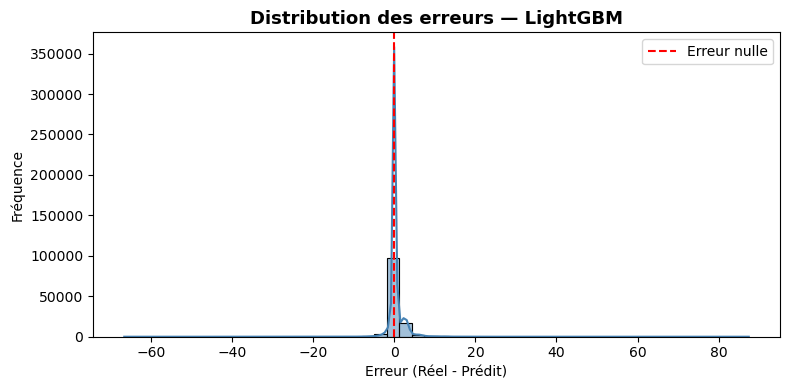

Erreur moyenne : 0.576
Ecart-type des erreurs : 2.133


In [31]:
# Distribution des erreurs - LightGBM
errors_lgbm = y_test.values - lgb_model.predict(X_test)

plt.figure(figsize=(8, 4))
sns.histplot(errors_lgbm, bins=50, kde=True, color='steelblue')
plt.title('Distribution des erreurs — LightGBM', fontsize=13, fontweight='bold')
plt.xlabel('Erreur (Réel - Prédit)')
plt.ylabel('Fréquence')
plt.axvline(0, color='red', linestyle='--', label='Erreur nulle')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Erreur moyenne : {errors_lgbm.mean():.3f}")
print(f"Ecart-type des erreurs : {errors_lgbm.std():.3f}")

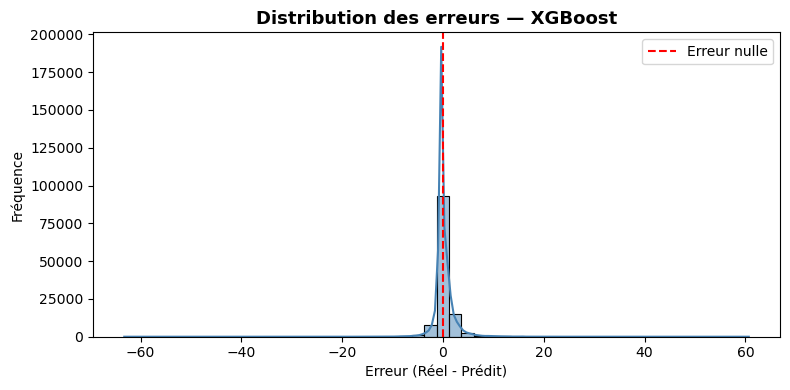

Erreur moyenne : 0.155
Ecart-type des erreurs : 2.127


In [32]:
# Distribution des erreurs - XGBoost
errors_xgb = y_test.values - xgb_model.predict(X_test)

plt.figure(figsize=(8, 4))
sns.histplot(errors_xgb, bins=50, kde=True, color='steelblue')
plt.title('Distribution des erreurs — XGBoost', fontsize=13, fontweight='bold')
plt.xlabel('Erreur (Réel - Prédit)')
plt.ylabel('Fréquence')
plt.axvline(0, color='red', linestyle='--', label='Erreur nulle')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Erreur moyenne : {errors_xgb.mean():.3f}")
print(f"Ecart-type des erreurs : {errors_xgb.std():.3f}")


## Interprétation finale et choix du modèle

**Importance des features**

Les deux modèles s'accordent : `rolling_mean_7` domine largement (0.715 XGBoost, 
0.694 régression). L'historique récent est le meilleur prédicteur, cohérent 
avec sa corrélation de 0.77 dans la matrice.

`month` arrive en 2ème position dans les deux malgré une corrélation faible (-0.06). 
Les deux modèles captent une saisonnalité mensuelle que Pearson ne détectait pas.

La différence clé : `item_id_enc` vaut 0.022 dans XGBoost mais 0.000 en régression. 
La régression ne différencie pas les produits entre eux, XGBoost oui. Même constat 
pour `event_enc` (0.022 vs 0.004).

`store_id_enc` a une faible importance dans les deux mais ce n'est pas une anomalie : 
les lags calculés par magasin via `groupby` portent déjà implicitement 
l'information du magasin.

**Pourquoi XGBoost**

LightGBM a le meilleur MAE (1.010) mais le biais le plus fort (0.576). 
XGBoost a un MAE de 1.072, le meilleur RMSE (2.133) et le biais le plus 
faible (0.155), soit 61% de moins que la régression linéaire. 
Dans un contexte supply chain sous-estimer = rupture de stock. 
XGBoost est le seul modèle à vraiment utiliser `item_id_enc` 
ce qui est indispensable pour prédire par produit.

**Les limites et comment on les compense**

`event_enc` a une importance faible car les 180 derniers jours du dataset 
ont presque tous un event dans le calendrier M5. Le modèle prédit bien 
les jours normaux (26 jours sur 28) mais pas les pics d'events.

Pour Memorial Day et Father's Day les alertes du Streamlit compensent 
cette limite. Elles calculent les unités supplémentaires à commander 
en appliquant les impacts historiques mesurés en exploration sur 
la moyenne des ventes du magasin. Par exemple pour CA_1 le 30 mai :
- Prévision modèle --> 900 unités
- Alerte Memorial Day -_> +35% historique
- Commande recommandée --> 1215 unités

C'est l'intégration ML + Recherche Opérationnelle : 
le modèle gère la tendance de fond, les alertes gèrent les exceptions.

## 6. Export du modèle pour le Streamlit

On sauvegarde le modèle final et les fichiers nécessaires pour que le Streamlit puisse les charger directement sans réentraîner le modèle à chaque fois.

In [33]:
import joblib
import os

# Sauvegarde sur le Bureau
dossier = '/Users/maelys_thr/Desktop/Modeles_Magasins'
os.makedirs(dossier, exist_ok=True)

# Sauvegarde du modèle XGBoost final
joblib.dump(xgb_model, f'{dossier}/modele_xgboost_magasins.pkl')

# Sauvegarde des features
joblib.dump(features, f'{dossier}/features_magasins.pkl')

# Sauvegarde du LabelEncoder pour item_id
joblib.dump(le, f'{dossier}/label_encoder_magasins.pkl')

# Sauvegarde du MAE global
joblib.dump(round(mean_absolute_error(y_test, xgb_model.predict(X_test)), 3),
            f'{dossier}/mae_magasins.pkl')

# Sauvegarde des données test avec prédictions
test_save = test[['date', 'store_id', 'item_id', 'sales']].copy()
test_save['prediction'] = xgb_model.predict(X_test)
test_save.to_csv(f'{dossier}/test_predictions_magasins.csv', index=False)

# Sauvegarde du MAE par magasin
mae_par_magasin = test.groupby('store_id').apply(
    lambda g: mean_absolute_error(g['sales'], xgb_model.predict(g[features]))
).round(3)
joblib.dump(mae_par_magasin, f'{dossier}/mae_par_magasin.pkl')

# Sauvegarde des données complètes pour les prévisions futures
joblib.dump(df_long, f'{dossier}/df_long_magasins.pkl')

print("Fichiers sauvegardés sur le Bureau dans Modeles_Magasins")

Fichiers sauvegardés sur le Bureau dans Modeles_Magasins
